# Análisis Exploratorio de Datos (EDA) — ACH Data
**Proyecto:** ACH Data Analytics · INNLAB (Universidad Icesi) para **ACH Colombia**
**Metodología:** CRISP-DM — este notebook cubre la fase 2 (*entendimiento de los datos*), apoyado en la fase 1 (*entendimiento del negocio*) resumida abajo y detallada en `Entendimiento_Negocio_y_Datos.md`.

---

## Contexto del negocio (resumen)

**ACH Colombia** es la infraestructura de pagos de bajo valor del sistema financiero colombiano: opera **ACH/Transfiya** (transferencias interbancarias), **PSE** (pagos digitales en línea) y **SOI/PILA** (recaudo de seguridad social). Está vigilada por la Superintendencia Financiera y procesa millones de operaciones al mes.

**El reto (ACH Data):** monetizar estos datos transaccionales como productos analíticos para terceros. A partir del diccionario de datos se construyó —mediante *triangulación analítica iterativa*— un catálogo de **105 modelos validados** en 12+ sectores, y el cliente priorizó **5 casos de uso**: ① Monitoreo y Alertas, ② Estimador de ingresos para independientes, ③ Flujo de caja, ④ Comportamientos de consumo, ⑤ Análisis y segmentos.

**Las tres fuentes de datos entregadas** (ofuscadas) alimentan directamente esos casos:

| Dataset | Sistema origen | Grano (una fila =) | Señal principal que aporta |
|---|---|---|---|
| Seguridad Social | SOI / PILA | persona × empleador × período cotizado | Ingreso formal verificado (IBC), estabilidad laboral (novedades ING/RET/VSP) |
| Transferencias ACH | ACH / Transfiya | persona × período × contraparte × sentido | Ingreso/egreso real visible en el canal interbancario |
| Pagos Digitales | PSE | persona × período × comercio | Capacidad y patrón de gasto por categoría de comercio |

**Notas críticas antes de leer el EDA:**
1. Los datos están **ofuscados**: nombres, documentos y entidades terminan en `****`. La llave de persona (`Número documento`) está enmascarada en sus últimos dígitos, por lo que la identidad es *aproximada* (posibles colisiones).
2. Transferencias y Pagos Digitales tienen exactamente **1.048.574 filas = límite de hoja de Excel**, es decir, son **muestras truncadas**, no el universo.
3. Cada dataset mezcla dos granos: columnas *agregadas* por persona o persona-período (prefijo `Promedio`/`Total`) repetidas en cada fila de detalle. En el EDA se de-duplican antes de analizar los agregados.

---
## 1 · Setup y carga de datos

Los Excel (60–110 MB) se convierten una única vez a **parquet** (`Data/processed/`); las ejecuciones siguientes cargan directo del caché. Todo se lee como texto y los tipos se convierten de forma controlada en cada sección.

In [1]:
# === Setup: librerías, paleta y helpers ===
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

# --- Paleta categórica validada (orden fijo, no ciclar) ---
CAT = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834', '#4a3aa7', '#e34948']
AZUL, VERDE, ROJO = CAT[0], CAT[1], CAT[7]
CMAP_SEQ = LinearSegmentedColormap.from_list(
    'seq_azul', ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
CMAP_DIV = LinearSegmentedColormap.from_list('div', ['#e34948', '#f0efec', '#2a78d6'])

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e',
    'axes.titlecolor': '#0b0b0b', 'axes.titleweight': 'semibold', 'axes.titlesize': 11.5,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': '#898781', 'ytick.color': '#898781',
    'text.color': '#0b0b0b', 'font.size': 10.5, 'figure.dpi': 105,
    'axes.prop_cycle': plt.cycler(color=CAT),
})

def fmt_es(x, dec=0):
    """1234567.8 -> '1.234.568' (formato es-CO)."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

FMT_MILL = mticker.FuncFormatter(lambda v, p: fmt_es(v / 1e6) + ' M')
FMT_MILES = mticker.FuncFormatter(lambda v, p: fmt_es(v))

def tabla_nulos(df):
    n = df.isna().sum()
    t = pd.DataFrame({'n_nulos': n, 'pct_nulos': (n / len(df) * 100).round(2)})
    return t[t.n_nulos > 0].sort_values('pct_nulos', ascending=False)

def barras_nulos(df, titulo):
    t = tabla_nulos(df)
    if t.empty:
        print('✔ Sin valores nulos en ninguna columna.')
        return
    fig, ax = plt.subplots(figsize=(8.5, max(1.8, 0.4 * len(t))))
    ax.barh(t.index[::-1], t.pct_nulos[::-1], color=AZUL, height=0.6)
    for i, v in enumerate(t.pct_nulos[::-1]):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9, color='#52514e')
    ax.set_xlim(0, 118); ax.set_xlabel('% de registros nulos')
    ax.set_title(titulo, loc='left')
    plt.tight_layout(); plt.show()

def barh_conteo(serie, titulo, top=None, color=AZUL, pct=True, figsize=None):
    vc = serie.value_counts().head(top) if top else serie.value_counts()
    total = len(serie.dropna())
    fig, ax = plt.subplots(figsize=figsize or (8.5, max(1.8, 0.42 * len(vc))))
    etiquetas = [str(x)[:55] for x in vc.index[::-1]]
    ax.barh(etiquetas, vc.values[::-1], color=color, height=0.6)
    for i, v in enumerate(vc.values[::-1]):
        txt = f'{fmt_es(v)} ({v/total*100:.1f}%)' if pct else fmt_es(v)
        ax.text(v + vc.max() * 0.01, i, txt, va='center', fontsize=9, color='#52514e')
    ax.set_xlim(0, vc.max() * 1.30)
    ax.xaxis.set_major_formatter(FMT_MILES)
    ax.set_title(titulo, loc='left')
    plt.tight_layout(); plt.show()
    return vc

def perfil(df, nombre):
    print(f'— {nombre} —')
    print(f'Dimensiones      : {fmt_es(df.shape[0])} filas × {df.shape[1]} columnas')
    print(f'Memoria en RAM   : {df.memory_usage(deep=True).sum()/1e6:,.0f} MB')
    print(f'Filas duplicadas : {fmt_es(df.duplicated().sum())}')

M = {}  # métricas clave del EDA → Data/processed/eda_metrics.json
print('Setup listo.')

Setup listo.


In [2]:
# === Carga con caché parquet ===
BASE = Path.cwd()
DATA, PROC = BASE / 'Data', BASE / 'Data' / 'processed'
PROC.mkdir(exist_ok=True)
LIMITE_EXCEL = 1_048_575  # filas máx. de una hoja xlsx (incluye encabezado)

FUENTES = {
    'ss':   'Conversion Seguridad Social 1 - Ofuscado',
    'tr':   'Conversion Transferencias ACH 1 - Ofuscado',
    'pdig': 'Conversion Pagos Digitales 1 - Ofuscado',
}

def cargar(clave):
    pq = PROC / f'{FUENTES[clave]}.parquet'
    if pq.exists():
        return pd.read_parquet(pq)
    df = pd.read_excel(DATA / f'{FUENTES[clave]}.xlsx', sheet_name=0, dtype=str)
    df.to_parquet(pq, index=False)
    return df

ss, tr, pdig = cargar('ss'), cargar('tr'), cargar('pdig')

for nombre, df in [('Seguridad Social (PILA)', ss), ('Transferencias ACH/Transfiya', tr),
                   ('Pagos Digitales (PSE)', pdig)]:
    trunc = ' ⚠ TRUNCADO al límite de Excel' if df.shape[0] >= LIMITE_EXCEL - 1 else ''
    print(f'{nombre:30s} {fmt_es(df.shape[0]):>10} filas × {df.shape[1]:>2} cols{trunc}')

M['filas'] = {'seguridad_social': len(ss), 'transferencias': len(tr), 'pagos_digitales': len(pdig)}

Seguridad Social (PILA)           743.406 filas × 31 cols
Transferencias ACH/Transfiya    1.048.574 filas × 26 cols ⚠ TRUNCADO al límite de Excel
Pagos Digitales (PSE)           1.048.574 filas × 12 cols ⚠ TRUNCADO al límite de Excel


---
## 2 · EDA — Seguridad Social (SOI / PILA)

**Grano:** una fila = un aporte de seguridad social de una **persona** con un **empleador/aportante** en un **período de cotización** (mes). Incluye:

- **Identificación** (ofuscada): persona (`Tipo de documento`, `Número de documento`) y aportante (`Razón social`, `Número documento`, actividad económica CIIU, clase/tipo de aportante).
- **Monetarias:** `Salario básico` e **IBC** (Ingreso Base de Cotización) para pensión, salud, caja de compensación y riesgos + versiones `Promedio …` pre-agregadas por persona.
- **Días cotizados** por subsistema (0–30) — `Días pensión = 0` con salud activa es la señal clásica de **independiente/informalidad** del catálogo.
- **`Novedades`** (multivaluado, separado por comas): Ingreso (ING), Retiro (RET), variaciones de salario (VSP/VST), incapacidades (IGE), vacaciones, etc. — insumo directo del caso de uso *Monitoreo y Alertas*.

Es la fuente del **piso de ingreso formal verificado** en la triangulación del *Estimador de Ingresos*.

In [3]:
# === 2.1 Conversión de tipos y primera vista ===
NUM_SS = ['Promedio salario básico', 'Promedio ingreso base pensión', 'Promedio ingreso base salud',
          'Promedio ingreso base caja compensación', 'Promedio ingreso base riesgos',
          'Salario básico', 'Ingreso base pensión', 'Días pensión', 'Ingreso base salud',
          'Días salud', 'Ingreso base caja compensación', 'Días caja compensación',
          'Ingreso base riesgos', 'Días riesgos']
for c in NUM_SS:
    ss[c] = pd.to_numeric(ss[c], errors='coerce')
ss['Fecha de pago'] = pd.to_datetime(ss['Fecha de pago'], errors='coerce')
ss['periodo'] = pd.PeriodIndex(ss['Periodo cotización'], freq='M')
for c in ['Tipo de documento', 'Tipo documento', 'Clase aportante', 'Tipo aportante',
          'Tipo planilla', 'Relación laboral', 'Tipo salario']:
    ss[c] = ss[c].astype('category')

ss.head(3)

,Nombre,Tipo de documento,Número de documento,Promedio salario básico,Promedio ingreso base pensión,Promedio ingreso base salud,Promedio ingreso base caja compensación,Promedio ingreso base riesgos,Razón social,Tipo documento,Número documento,Código actividad económica,Actividad económica,Clase aportante,Tipo aportante,Fecha de pago,Periodo cotización,Empleador,Tipo planilla,Relación laboral,Salario básico,Tipo salario,Novedades,Ingreso base pensión,Días pensión,Ingreso base salud,Días salud,Ingreso base caja compensación,Días caja compensación,Ingreso base riesgos,Días riesgos,periodo
0,************TIAN OSORIO GOMEZ,P,23200004****,1639916,0,1973824,0,291219,TOTALS********,J,20890786****,4771,Comercio al por menor de prendas de vestir y s...,EMPRESAS CON MENOS DE 200 COTIZANTES,EMPLEADOR,2026-06-11,2026-06,TOTALS********,E,DEPENDIENTE,1875905,F,"Variación transitoria de salario,Incapacidad p...",0,0,3008926,30,0,0,3008926,30,2026-06
1,************TIAN OSORIO GOMEZ,P,23200004****,1639916,0,1973824,0,291219,TOTALS********,J,20890786****,4771,Comercio al por menor de prendas de vestir y s...,EMPRESAS CON MENOS DE 200 COTIZANTES,EMPLEADOR,2026-05-12,2026-05,TOTALS********,E,DEPENDIENTE,1875905,F,"Variación transitoria de salario,Incapacidad p...",0,0,2118868,30,0,0,2118868,30,2026-05
2,************TIAN OSORIO GOMEZ,P,23200004****,1639916,0,1973824,0,291219,TOTALS********,J,20890786****,4771,Comercio al por menor de prendas de vestir y s...,EMPRESAS CON MENOS DE 200 COTIZANTES,EMPLEADOR,2026-04-15,2026-04,TOTALS********,E,DEPENDIENTE,1875905,F,"Ingreso,Variación transitoria de salario",0,0,1849670,26,0,0,1849670,26,2026-04


— Seguridad Social —
Dimensiones      : 743.406 filas × 32 columnas


Memoria en RAM   : 578 MB


Filas duplicadas : 50
Ventana temporal : 2023-07 → 2026-06  (36 períodos)



,n_nulos,pct_nulos
Novedades,279273,37.57
Tipo salario,109578,14.74
Tipo planilla,383,0.05


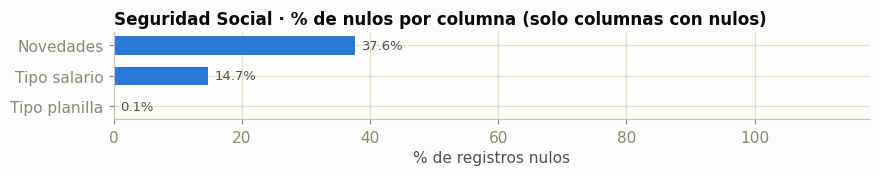

In [4]:
# === 2.2 Perfil general y valores nulos ===
perfil(ss, 'Seguridad Social')
print(f"Ventana temporal : {ss['periodo'].min()} → {ss['periodo'].max()}"
      f"  ({ss['periodo'].nunique()} períodos)")
print()
display(tabla_nulos(ss))
barras_nulos(ss, 'Seguridad Social · % de nulos por columna (solo columnas con nulos)')

Personas únicas (doc. enmascarado) : 33.281
Aportantes/empleadores únicos      : 29.957
Registros por persona              : mediana 21 · p90 38 · máx 374


Empleadores por persona            : mediana 2 · p90 5 · máx 28


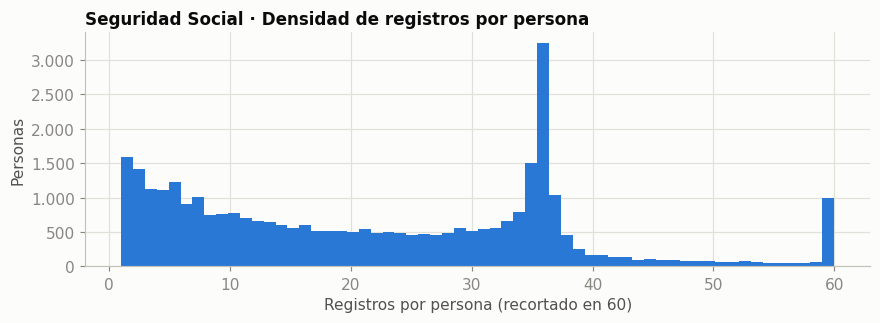

In [5]:
# === 2.3 Cobertura: personas, aportantes y densidad de registros ===
n_personas = ss['Número de documento'].nunique()
n_aportantes = ss['Número documento'].nunique()
rpp = ss.groupby('Número de documento', observed=True).size()

print(f'Personas únicas (doc. enmascarado) : {fmt_es(n_personas)}')
print(f'Aportantes/empleadores únicos      : {fmt_es(n_aportantes)}')
print(f'Registros por persona              : mediana {fmt_es(rpp.median())} · '
      f'p90 {fmt_es(rpp.quantile(0.9))} · máx {fmt_es(rpp.max())}')
emp_por_persona = ss.groupby('Número de documento', observed=True)['Número documento'].nunique()
print(f'Empleadores por persona            : mediana {fmt_es(emp_por_persona.median())} · '
      f'p90 {fmt_es(emp_por_persona.quantile(0.9))} · máx {fmt_es(emp_por_persona.max())}')

M['ss'] = {'personas': int(n_personas), 'aportantes': int(n_aportantes),
           'periodos': [str(ss['periodo'].min()), str(ss['periodo'].max())],
           'reg_por_persona_mediana': float(rpp.median())}

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.hist(rpp.clip(upper=60), bins=60, color=AZUL)
ax.set_xlabel('Registros por persona (recortado en 60)'); ax.set_ylabel('Personas')
ax.yaxis.set_major_formatter(FMT_MILES)
ax.set_title('Seguridad Social · Densidad de registros por persona', loc='left')
plt.tight_layout(); plt.show()

,count,mean,std,min,5%,25%,50%,75%,95%,max,pct_cero
Salario básico,743406.0,2933906.0,4299941.0,0.0,1160000.0,1358795.0,1689853.0,2740000.0,8653228.0,201423500.0,1.0
Ingreso base pensión,743406.0,796474.0,2742878.0,0.0,0.0,0.0,0.0,0.0,4797635.0,79082859.0,81.0
Ingreso base salud,743406.0,1993333.0,3257625.0,0.0,0.0,0.0,1423500.0,2100000.0,7359672.0,79082859.0,29.0
Ingreso base caja compensación,743406.0,351547.0,1804365.0,0.0,0.0,0.0,0.0,0.0,1960762.0,505896643.0,88.0
Ingreso base riesgos,743406.0,1321137.0,2822909.0,0.0,0.0,0.0,0.0,1749564.0,5823462.0,43772625.0,57.0


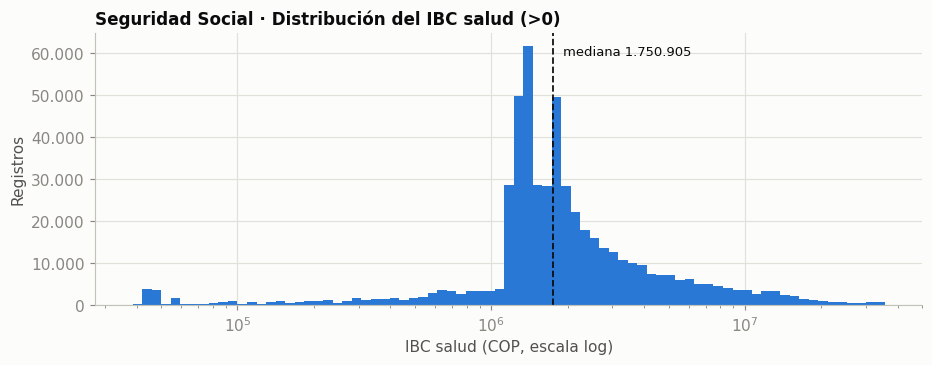

El pico concentrado cerca de 1.300.001 COP corresponde al salario mínimo legal (fenómeno esperado en Colombia).


In [6]:
# === 2.4 Univariado numérico: salario e IBC ===
cols_dinero = ['Salario básico', 'Ingreso base pensión', 'Ingreso base salud',
               'Ingreso base caja compensación', 'Ingreso base riesgos']
desc = ss[cols_dinero].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc['pct_cero'] = [(ss[c] == 0).mean() * 100 for c in cols_dinero]
display(desc.round(0))

# Distribución (escala log) del IBC salud — la base más completa
vals = ss.loc[ss['Ingreso base salud'] > 0, 'Ingreso base salud']
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(vals, bins=np.logspace(np.log10(vals.quantile(0.001)), np.log10(vals.quantile(0.999)), 80),
        color=AZUL)
ax.set_xscale('log')
ax.axvline(vals.median(), color='#0b0b0b', lw=1.2, ls='--')
ax.text(vals.median() * 1.1, ax.get_ylim()[1] * 0.92, f'mediana {fmt_es(vals.median())}',
        fontsize=9, color='#0b0b0b')
ax.set_xlabel('IBC salud (COP, escala log)'); ax.set_ylabel('Registros')
ax.yaxis.set_major_formatter(FMT_MILES)
ax.set_title('Seguridad Social · Distribución del IBC salud (>0)', loc='left')
plt.tight_layout(); plt.show()

M['ss']['ibc_salud_mediana'] = float(vals.median())
print(f"El pico concentrado cerca de {fmt_es(vals.quantile(0.25))} COP corresponde "
      "al salario mínimo legal (fenómeno esperado en Colombia).")

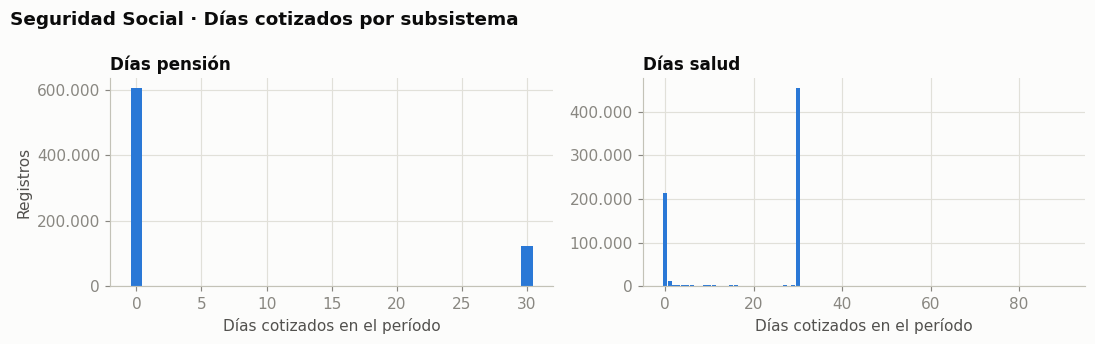

Registros con salud activa pero SIN cotización a pensión : 57.6%  ← señal de independientes/informalidad (S-informalidad del catálogo)
Registros con mes completo de salud (30 días)             : 61.0%


In [7]:
# === 2.4b Días cotizados y señal de informalidad/independientes ===
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
for ax, col in zip(axes, ['Días pensión', 'Días salud']):
    vc = ss[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=AZUL, width=0.9)
    ax.set_title(col, loc='left'); ax.set_xlabel('Días cotizados en el período')
    ax.yaxis.set_major_formatter(FMT_MILES)
axes[0].set_ylabel('Registros')
fig.suptitle('Seguridad Social · Días cotizados por subsistema', x=0.01, ha='left',
             fontweight='semibold')
plt.tight_layout(); plt.show()

sin_pension = ((ss['Días pensión'] == 0) & (ss['Días salud'] > 0)).mean() * 100
dias30 = (ss['Días salud'] == 30).mean() * 100
print(f'Registros con salud activa pero SIN cotización a pensión : {sin_pension:.1f}%  '
      '← señal de independientes/informalidad (S-informalidad del catálogo)')
print(f'Registros con mes completo de salud (30 días)             : {dias30:.1f}%')
M['ss']['pct_salud_sin_pension'] = round(float(sin_pension), 2)

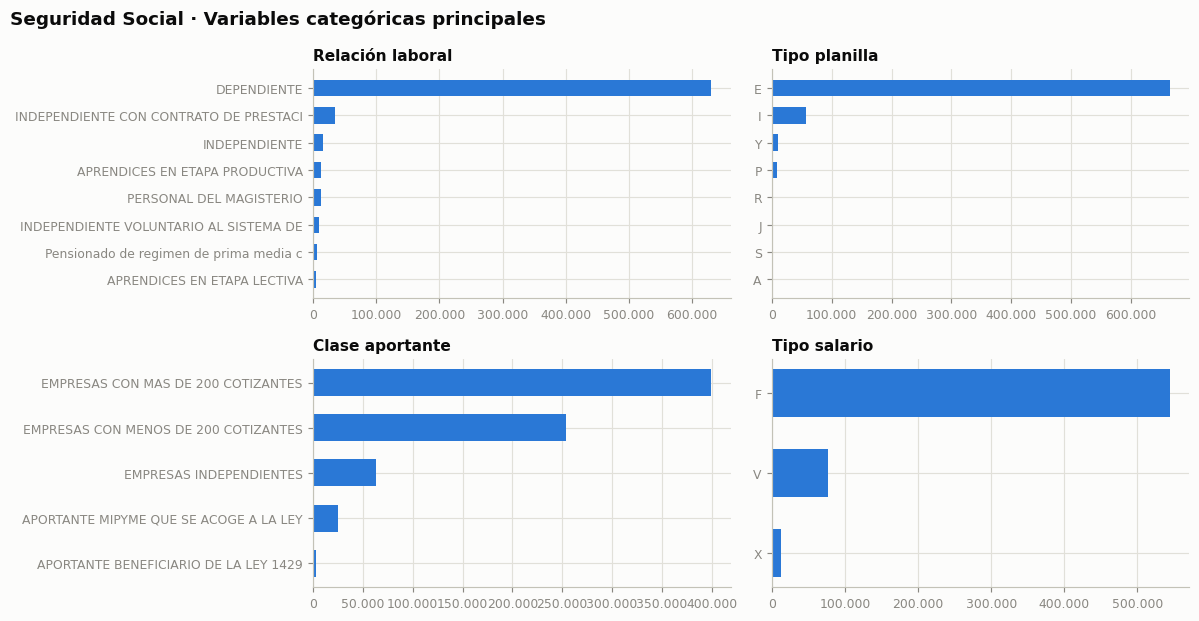

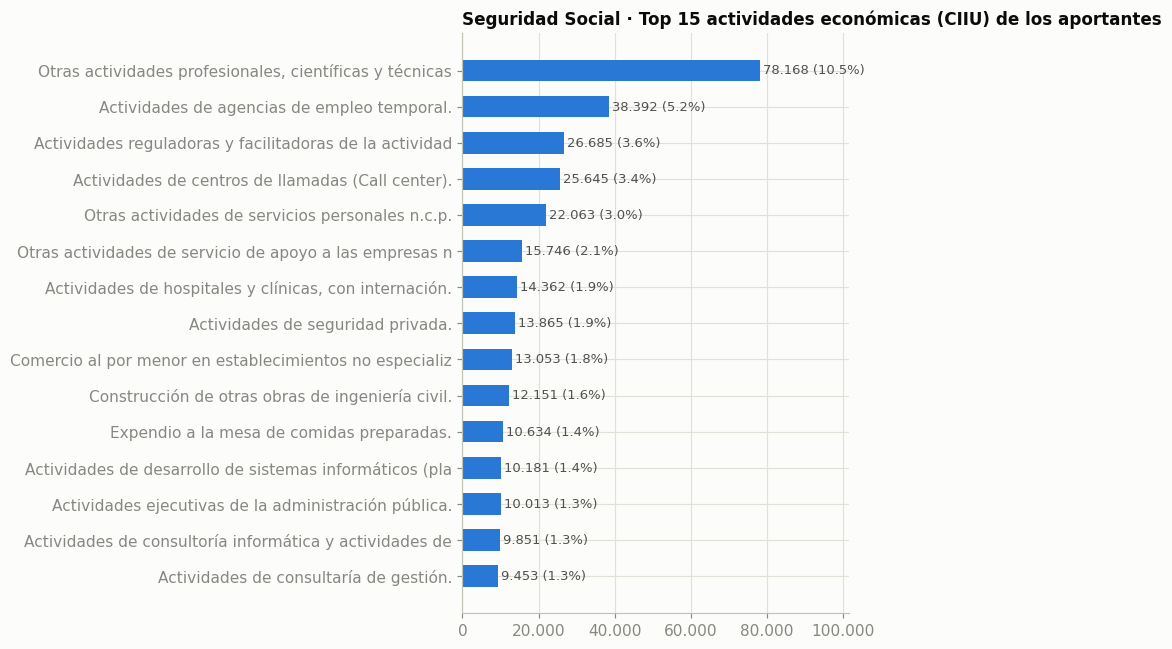

Actividad económica
Otras actividades profesionales, científicas y técnicas n.c.    78168
Actividades de agencias de empleo temporal.                     38392
Actividades reguladoras y facilitadoras de la actividad econ    26685
Actividades de centros de llamadas (Call center).               25645
Otras actividades de servicios personales n.c.p.                22063
Otras actividades de servicio de apoyo a las empresas n.c.p.    15746
Actividades de hospitales y clínicas, con internación.          14362
Actividades de seguridad privada.                               13865
Comercio al por menor en establecimientos no especializados     13053
Construcción de otras obras de ingeniería civil.                12151
Expendio a la mesa de comidas preparadas.                       10634
Actividades de desarrollo de sistemas informáticos (planific    10181
Actividades ejecutivas de la administración pública.            10013
Actividades de consultoría informática y actividades de admi     9851


In [8]:
# === 2.5 Univariado categórico ===
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6))
for ax, col in zip(axes.ravel(), ['Relación laboral', 'Tipo planilla', 'Clase aportante', 'Tipo salario']):
    vc = ss[col].value_counts().head(8)
    etiquetas = [str(x)[:38] for x in vc.index[::-1]]
    ax.barh(etiquetas, vc.values[::-1], color=AZUL, height=0.6)
    ax.set_title(col, loc='left', fontsize=10.5)
    ax.xaxis.set_major_formatter(FMT_MILES)
    ax.tick_params(labelsize=8.5)
fig.suptitle('Seguridad Social · Variables categóricas principales', x=0.01, ha='left',
             fontweight='semibold')
plt.tight_layout(); plt.show()

barh_conteo(ss['Actividad económica'].str.slice(0, 60),
            'Seguridad Social · Top 15 actividades económicas (CIIU) de los aportantes', top=15)

Registros con al menos una novedad: 62.4%


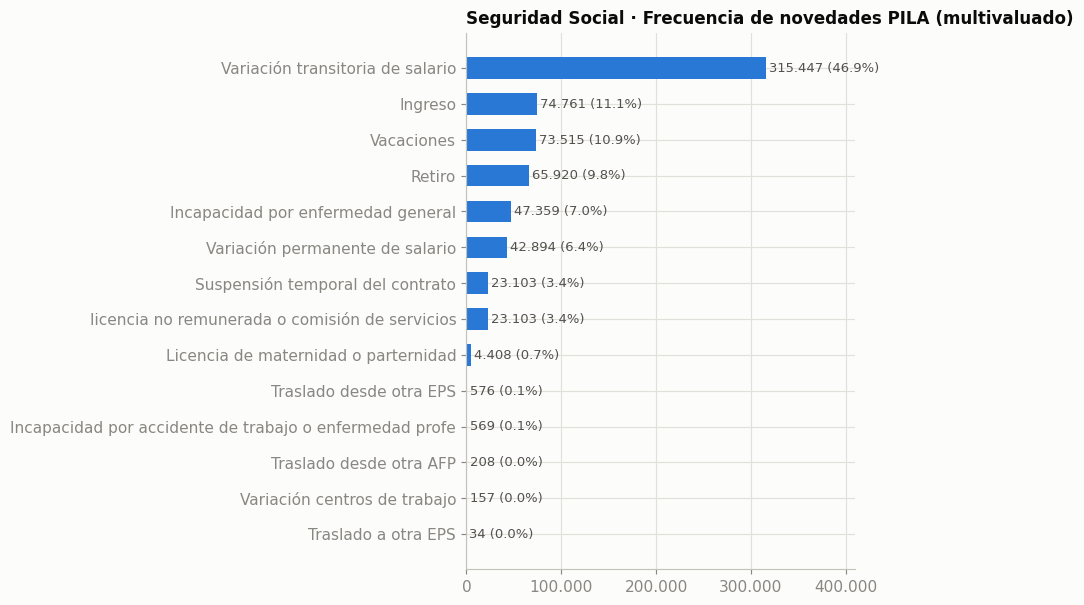

,% de registros
Ingreso (ING) — inicio rel. laboral,10.06
Retiro (RET) — fin rel. laboral,8.87
Variación permanente salario (VSP),5.77
Variación transitoria salario (VST),42.43
Incapacidad enf. general (IGE),6.44
Suspensión / licencia (SLN),3.69
Vacaciones (VAC),9.89


In [9]:
# === 2.6 Novedades: el insumo del caso 'Monitoreo y Alertas' ===
nov = (ss['Novedades'].dropna().str.split(',').explode().str.strip())
pct_con_novedad = ss['Novedades'].notna().mean() * 100
print(f'Registros con al menos una novedad: {pct_con_novedad:.1f}%')
vc_nov = barh_conteo(nov, 'Seguridad Social · Frecuencia de novedades PILA (multivaluado)', top=14)

# Señales específicas del motor de alertas
tiene = lambda pat: ss['Novedades'].str.contains(pat, case=False, na=False)
senales = pd.Series({
    'Ingreso (ING) — inicio rel. laboral': tiene(r'^Ingreso$|,\s*Ingreso$|^Ingreso,|,\s*Ingreso,').mean(),
    'Retiro (RET) — fin rel. laboral': tiene('Retiro').mean(),
    'Variación permanente salario (VSP)': tiene('Variación permanente').mean(),
    'Variación transitoria salario (VST)': tiene('Variación transitoria').mean(),
    'Incapacidad enf. general (IGE)': tiene('Incapacidad').mean(),
    'Suspensión / licencia (SLN)': tiene('Suspensión|Licencia').mean(),
    'Vacaciones (VAC)': tiene('Vacaciones').mean(),
}) * 100
display(senales.round(2).to_frame('% de registros'))
M['ss']['pct_retiro'] = round(float(tiene('Retiro').mean() * 100), 2)
M['ss']['pct_ingreso'] = round(float(tiene(r'Ingreso').mean() * 100), 2)

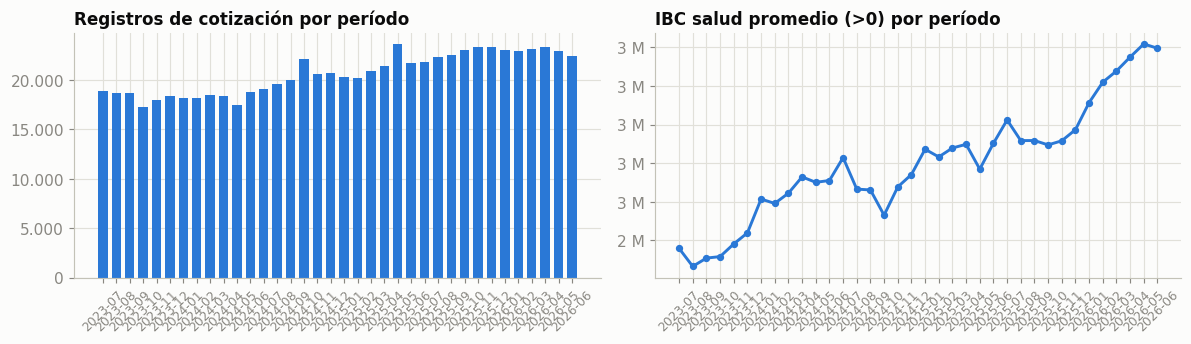

,registros,personas,ibc_salud_prom
periodo,,,
2023-07,18892,16940,2358194.0
2023-08,18627,16754,2264784.0
2023-09,18687,16795,2307763.0
2023-10,17292,15572,2315499.0
2023-11,18005,16178,2381119.0
2023-12,18419,16490,2438525.0
2024-01,18140,16382,2613843.0
2024-02,18145,16328,2591096.0
2024-03,18424,16553,2644275.0


In [10]:
# === 2.7 Evolución temporal ===
g = ss.groupby('periodo', observed=True).agg(
    registros=('Salario básico', 'size'),
    personas=('Número de documento', 'nunique'),
    ibc_salud_prom=('Ingreso base salud', lambda s: s[s > 0].mean()),
)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
x = g.index.astype(str)
axes[0].bar(x, g['registros'], color=AZUL, width=0.7)
axes[0].set_title('Registros de cotización por período', loc='left')
axes[0].yaxis.set_major_formatter(FMT_MILES)
axes[1].plot(x, g['ibc_salud_prom'], color=AZUL, lw=2, marker='o', ms=4)
axes[1].set_title('IBC salud promedio (>0) por período', loc='left')
axes[1].yaxis.set_major_formatter(FMT_MILL)
for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=8.5)
plt.tight_layout(); plt.show()
display(g.round(0))

,% de registros
Días fuera de rango (>30) en algún subsistema,0.03
Salario básico = 0,0.53
IBC salud = 0 (sin base de salud),29.20
IBC pensión > 0 y ≠ IBC salud (bases distintas),4.99
Fecha de pago anterior al período cotizado,4.26


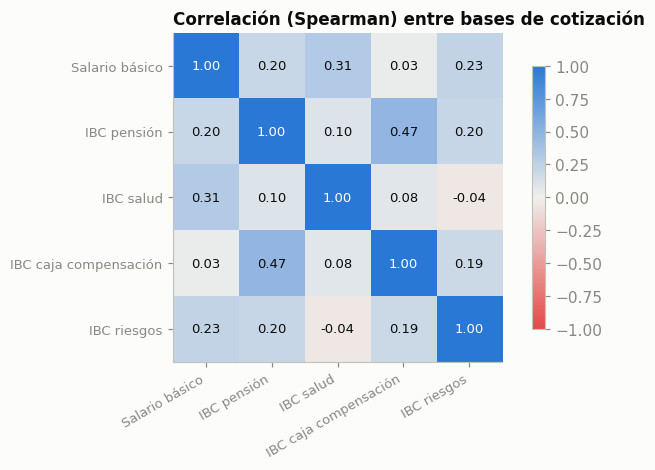

In [11]:
# === 2.8 Consistencia y coherencia interna ===
chk = pd.Series({
    'Días fuera de rango (>30) en algún subsistema':
        ((ss[['Días pensión', 'Días salud', 'Días caja compensación', 'Días riesgos']] > 30).any(axis=1)).mean(),
    'Salario básico = 0': (ss['Salario básico'] == 0).mean(),
    'IBC salud = 0 (sin base de salud)': (ss['Ingreso base salud'] == 0).mean(),
    'IBC pensión > 0 y ≠ IBC salud (bases distintas)':
        ((ss['Ingreso base pensión'] > 0) & (ss['Ingreso base pensión'] != ss['Ingreso base salud'])).mean(),
    'Fecha de pago anterior al período cotizado':
        (ss['Fecha de pago'].dt.to_period('M') < ss['periodo']).mean(),
}) * 100
display(chk.round(2).to_frame('% de registros'))

corr = ss[['Salario básico', 'Ingreso base pensión', 'Ingreso base salud',
           'Ingreso base caja compensación', 'Ingreso base riesgos']].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.8, 4.6))
im = ax.imshow(corr, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), [c.replace('Ingreso base ', 'IBC ') for c in corr.columns],
              rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(corr)), [c.replace('Ingreso base ', 'IBC ') for c in corr.columns], fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else '#0b0b0b')
ax.grid(False)
ax.set_title('Correlación (Spearman) entre bases de cotización', loc='left')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Lectura de la sección 2.** El dataset PILA aporta el *piso de ingreso formal verificado por el Estado*: quién cotiza, sobre qué base, cuántos días y con qué novedades. Las brechas (salud sin pensión, salario en mínimo, novedades RET/ING encadenadas) son exactamente las señales latentes S1/S7/S50 que la metodología del catálogo identificó para los casos de *Monitoreo*, *Ingresos de independientes* y *scoring alternativo*.

---
## 3 · EDA — Transferencias ACH / Transfiya

**Grano:** una fila = el agregado de transferencias de una **persona** en un **período**, por **contraparte** (entidad/usuario), **servicio** (`ACH` tradicional o `Transfiya` inmediata) y **sentido** (`RECIBIDO`/`ENVIADO`). Además trae agregados pre-calculados por persona (`Promedio …`) y por persona-período (`Total/Cantidad/Valor promedio … periodo`).

Campos clave para el negocio: `Valor` y `Cantidad de transferencias` (flujo real de dinero), `Cuenta propia` (transferencias a cuentas del mismo titular — señal de estructuración/autolavado en el catálogo), entidades origen/destino (red interbancaria).

⚠ **Este dataset está truncado en el límite de Excel (1.048.574 filas)** — los resultados describen la muestra, no el universo.

In [12]:
# === 3.1 Conversión de tipos y primera vista ===
NUM_TR = ['Promedio ACH recibidas', 'Promedio Transfiya recibidas', 'Promedio ACH enviadas',
          'Promedio Transfiya enviadas', 'Total recibidas periodo', 'Cantidad recibidas periodo',
          'Valor promedio recibidas periodo', 'Total enviadas periodo', 'Cantidad enviadas periodo',
          'Valor promedio enviadas periodo', 'Cantidad de transferencias', 'Valor']
for c in NUM_TR:
    tr[c] = pd.to_numeric(tr[c], errors='coerce')
tr['periodo'] = pd.PeriodIndex(tr['Periodo'], freq='M')
for c in ['Tipo documento', 'Servicio', 'Tipo registro', 'Tipo de cuenta', 'Cuenta propia']:
    tr[c] = tr[c].astype('category')

tr.head(3)

,Nombre,Tipo documento,Número documento,Promedio ACH recibidas,Promedio Transfiya recibidas,Promedio ACH enviadas,Promedio Transfiya enviadas,Periodo,Total recibidas periodo,Cantidad recibidas periodo,Valor promedio recibidas periodo,Total enviadas periodo,Cantidad enviadas periodo,Valor promedio enviadas periodo,Servicio,Tipo registro,Tipo de cuenta,Entidad origen,Usuario originador,Nombre usuario originador,Entidad destino,Usuario receptor,Nombre usuario receptor,Cuenta propia,Cantidad de transferencias,Valor,periodo
0,************O,P,23200004****,138565,1549920,13000,1728130,2026-02,323900.00,2,161950.00,0.0,0,0.0,ACH,RECIBIDO,OTRO,BAN********,9********,MIDAT********,None,None,None,NO,1,23900.0,2026-02
1,************O,P,23200004****,138565,1549920,13000,1728130,2026-02,323900.00,2,161950.00,0.0,0,0.0,ACH,RECIBIDO,AHORROS,DA********,10********,ALLISON ********,None,None,None,NO,1,300000.0,2026-02
2,************O,P,23200004****,138565,1549920,13000,1728130,2026-01,76852.61,4,19213.15,0.0,0,0.0,ACH,RECIBIDO,OTRO,BAN********,9********,MIDAT********,None,None,None,NO,2,47800.0,2026-01


— Transferencias ACH/Transfiya —
Dimensiones      : 1.048.574 filas × 27 columnas


Memoria en RAM   : 579 MB


Filas duplicadas : 7.291
Ventana temporal : 2025-01 → 2026-06 (18 períodos)


Personas únicas  : 26.904



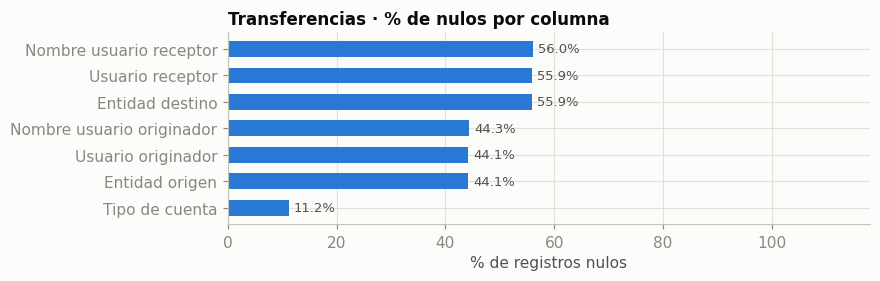

Los nulos de las columnas de contraparte son ESTRUCTURALES: dependen del sentido
(en RECIBIDO se conoce el originador; en ENVIADO, el receptor).


Usuario receptor,receptor presente,receptor nulo
Tipo registro,,
ENVIADO,1.0,0.0
RECIBIDO,0.0,1.0


In [13]:
# === 3.2 Perfil general y nulos ===
perfil(tr, 'Transferencias ACH/Transfiya')
print(f"Ventana temporal : {tr['periodo'].min()} → {tr['periodo'].max()} ({tr['periodo'].nunique()} períodos)")
print(f"Personas únicas  : {fmt_es(tr['Número documento'].nunique())}")
print()
barras_nulos(tr, 'Transferencias · % de nulos por columna')
print('Los nulos de las columnas de contraparte son ESTRUCTURALES: dependen del sentido')
print('(en RECIBIDO se conoce el originador; en ENVIADO, el receptor).')
display(pd.crosstab(tr['Tipo registro'], tr['Usuario receptor'].isna(), normalize='index')
        .rename(columns={True: 'receptor nulo', False: 'receptor presente'}).round(3))

M['tr'] = {'personas': int(tr['Número documento'].nunique()),
           'periodos': [str(tr['periodo'].min()), str(tr['periodo'].max())]}

Tipo registro,ENVIADO,RECIBIDO
Servicio,,
ACH,117264,252205
TRANSFIYA,345477,333628


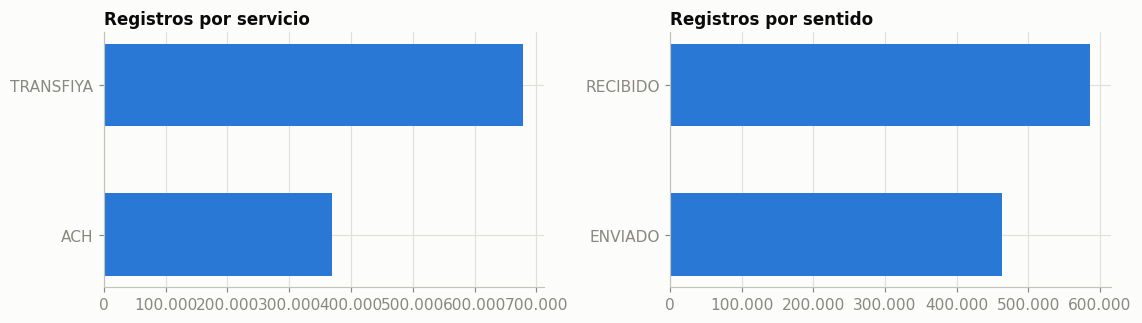

Transferencias marcadas a CUENTA PROPIA: 19.3% de los registros


In [14]:
# === 3.3 Composición: servicio × sentido ===
comp = pd.crosstab(tr['Servicio'], tr['Tipo registro'])
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
vc = tr['Servicio'].value_counts()
axes[0].barh(vc.index.astype(str)[::-1], vc.values[::-1], color=AZUL, height=0.55)
axes[0].set_title('Registros por servicio', loc='left')
vc2 = tr['Tipo registro'].value_counts()
axes[1].barh(vc2.index.astype(str)[::-1], vc2.values[::-1], color=AZUL, height=0.55)
axes[1].set_title('Registros por sentido', loc='left')
for ax in axes:
    ax.xaxis.set_major_formatter(FMT_MILES)
plt.tight_layout(); plt.show()

pct_propia = (tr['Cuenta propia'] == 'SI').mean() * 100
print(f'Transferencias marcadas a CUENTA PROPIA: {pct_propia:.1f}% de los registros')
M['tr']['pct_cuenta_propia'] = round(float(pct_propia), 2)

,count,mean,std,min,5%,25%,50%,75%,95%,max
Valor,1048574.0,664467.3,4238614.7,0.0,5000.0,26650.0,123000.0,569040.0,2776000.0,3.000000e+09
Cantidad de transferencias,1048574.0,2.0,2.9,1.0,1.0,1.0,1.0,2.0,6.0,1.820000e+02


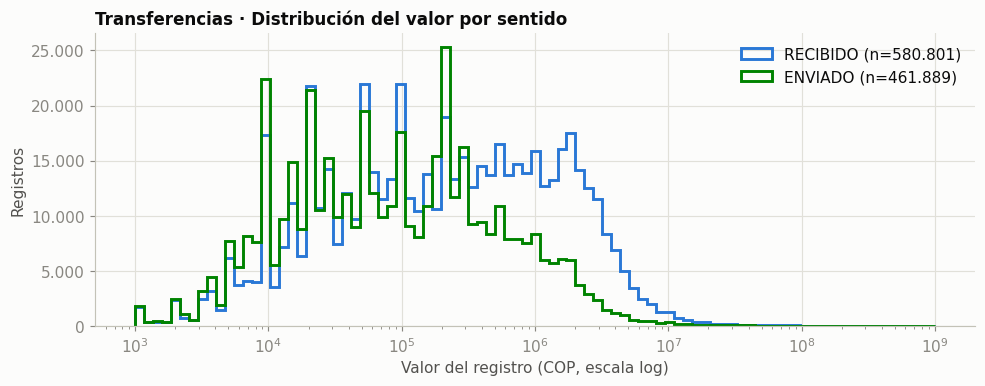

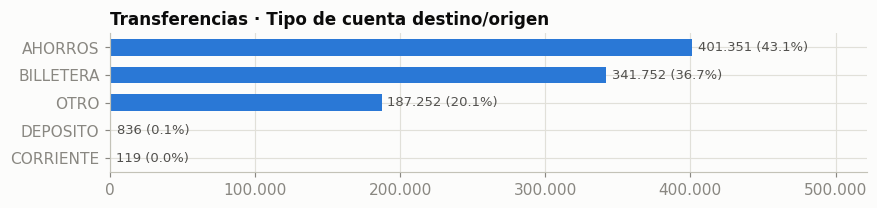

Tipo de cuenta
AHORROS      401351
BILLETERA    341752
OTRO         187252
DEPOSITO        836
CORRIENTE       119
Name: count, dtype: int64

In [15]:
# === 3.4 Distribución de valores y tipos de cuenta ===
display(tr[['Valor', 'Cantidad de transferencias']].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(1))

fig, ax = plt.subplots(figsize=(9.5, 3.8))
bins = np.logspace(3, 9, 90)
for color, sentido in [(AZUL, 'RECIBIDO'), (VERDE, 'ENVIADO')]:
    v = tr.loc[(tr['Tipo registro'] == sentido) & (tr['Valor'] > 0), 'Valor']
    ax.hist(v, bins=bins, histtype='step', lw=2, color=color, label=f'{sentido} (n={fmt_es(len(v))})')
ax.set_xscale('log')
ax.set_xlabel('Valor del registro (COP, escala log)'); ax.set_ylabel('Registros')
ax.yaxis.set_major_formatter(FMT_MILES)
ax.legend(frameon=False)
ax.set_title('Transferencias · Distribución del valor por sentido', loc='left')
plt.tight_layout(); plt.show()

barh_conteo(tr['Tipo de cuenta'], 'Transferencias · Tipo de cuenta destino/origen')

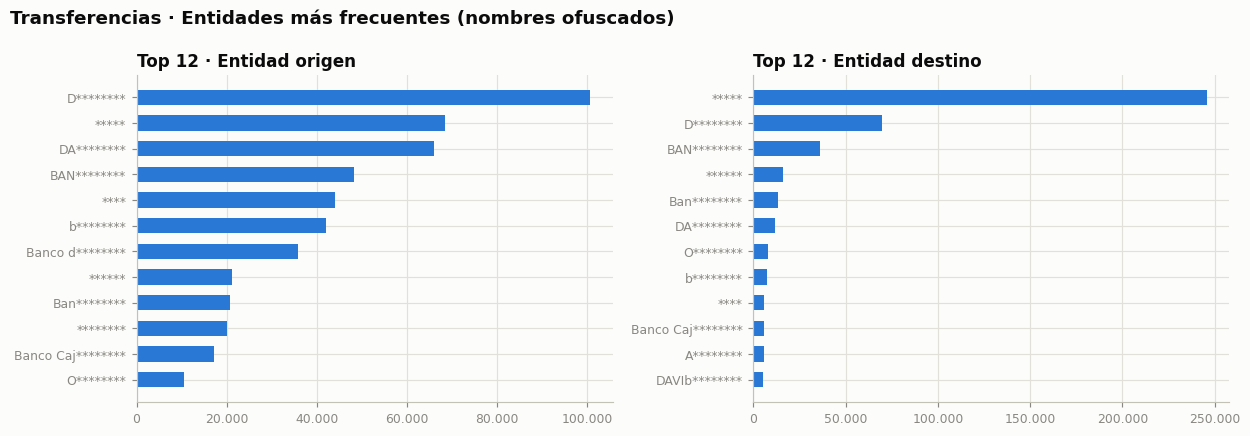

In [16]:
# === 3.5 Red interbancaria: principales entidades ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col in zip(axes, ['Entidad origen', 'Entidad destino']):
    vc = tr[col].value_counts().head(12)
    ax.barh([str(x)[:24] for x in vc.index[::-1]], vc.values[::-1], color=AZUL, height=0.6)
    ax.set_title(f'Top 12 · {col}', loc='left')
    ax.xaxis.set_major_formatter(FMT_MILES)
    ax.tick_params(labelsize=8.5)
fig.suptitle('Transferencias · Entidades más frecuentes (nombres ofuscados)', x=0.01,
             ha='left', fontweight='semibold')
plt.tight_layout(); plt.show()

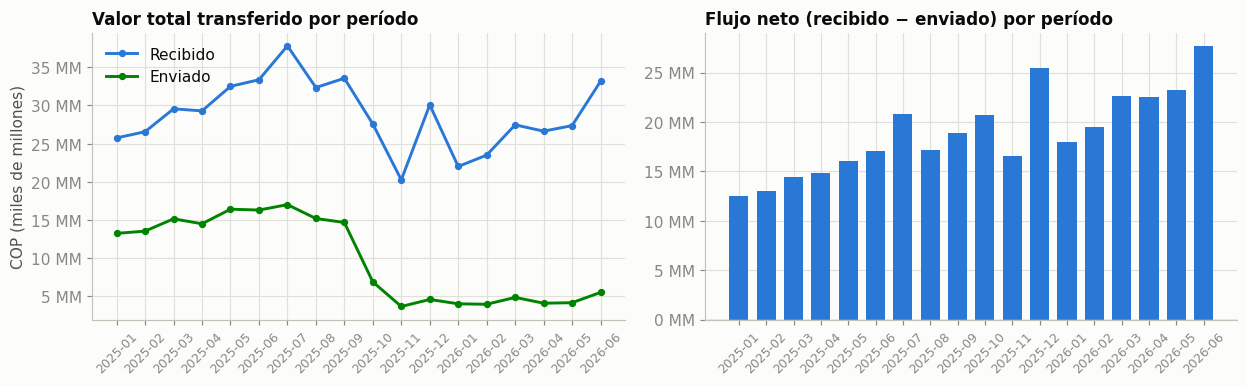

Tipo registro,ENVIADO,RECIBIDO
periodo,,
2025-01,1.325070e+10,2.575159e+10
2025-02,1.354846e+10,2.656207e+10
2025-03,1.515865e+10,2.955746e+10
2025-04,1.450824e+10,2.929090e+10
2025-05,1.641726e+10,3.250250e+10
2025-06,1.630691e+10,3.336716e+10
2025-07,1.701571e+10,3.780375e+10
2025-08,1.520134e+10,3.234841e+10
2025-09,1.467892e+10,3.355962e+10


In [17]:
# === 3.6 Evolución temporal: la base del Flujo de Caja Mensual (caso 3) ===
gt = (tr.groupby(['periodo', 'Tipo registro'], observed=True)['Valor'].sum()
        .unstack('Tipo registro').fillna(0))
x = gt.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(x, gt['RECIBIDO'], color=AZUL, lw=2, marker='o', ms=4, label='Recibido')
axes[0].plot(x, gt['ENVIADO'], color=VERDE, lw=2, marker='o', ms=4, label='Enviado')
axes[0].set_title('Valor total transferido por período', loc='left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: fmt_es(v/1e9) + ' MM'))
axes[0].set_ylabel('COP (miles de millones)')
axes[0].legend(frameon=False)

neto = gt['RECIBIDO'] - gt['ENVIADO']
axes[1].bar(x, neto, color=[AZUL if v >= 0 else ROJO for v in neto], width=0.7)
axes[1].axhline(0, color='#c3c2b7', lw=1)
axes[1].set_title('Flujo neto (recibido − enviado) por período', loc='left')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: fmt_es(v/1e9) + ' MM'))
for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=8.5)
plt.tight_layout(); plt.show()
display(gt.round(0))

In [18]:
# === 3.7 Coherencia de los agregados pre-calculados ===
# 'Total recibidas periodo' (persona-período) debería igualar la suma del detalle RECIBIDO.
det = (tr[tr['Tipo registro'] == 'RECIBIDO']
       .groupby(['Número documento', 'Periodo'], observed=True)['Valor'].sum())
agg = (tr.drop_duplicates(['Número documento', 'Periodo'])
         .set_index(['Número documento', 'Periodo'])['Total recibidas periodo'])
cmp_ = pd.concat([det.rename('suma_detalle'), agg.rename('agregado')], axis=1).dropna()
cmp_['diff_rel'] = (cmp_['suma_detalle'] - cmp_['agregado']).abs() / cmp_['agregado'].clip(lower=1)
ok = (cmp_['diff_rel'] < 0.01).mean() * 100
print(f'Pares persona-período evaluados          : {fmt_es(len(cmp_))}')
print(f'Agregado coincide con el detalle (±1%)    : {ok:.1f}%')
print('Las discrepancias restantes son consistentes con el TRUNCAMIENTO del archivo')
print('(filas de detalle que quedaron por fuera del límite de Excel).')
M['tr']['pct_agregado_coincide'] = round(float(ok), 1)

Pares persona-período evaluados          : 241.601
Agregado coincide con el detalle (±1%)    : 88.4%
Las discrepancias restantes son consistentes con el TRUNCAMIENTO del archivo
(filas de detalle que quedaron por fuera del límite de Excel).


**Lectura de la sección 3.** La fuente ACH/Transfiya captura el *flujo real de dinero* de las personas: cuánto reciben y envían por mes y con qué contrapartes. Es el numerador del **Flujo de Caja Mensual** (caso 3) y el "ingreso informal visible" del *Estimador de Ingresos* (caso 2). El campo `Cuenta propia` y la concentración por entidad habilitan además los modelos de anomalías (AML/estructuración) del catálogo.

---
## 4 · EDA — Pagos Digitales (PSE)

**Grano:** una fila = los pagos PSE de una **persona** en un **período** hacia un **comercio** (`Comercio`, `Cantidad`, `Valor`), con agregados por persona (`Promedio pagos digitales`) y por persona-período (`Total/Cantidad/Valor promedio … periodo`).

El campo `Comercio` es —según el propio catálogo— *"el mapa de consumo sin encuestas"*: su taxonomía (entidades públicas, financieras, turismo, streaming, educación, salud…) alimenta el caso ④ *Comportamientos de Consumo*.

⚠ **También truncado en el límite de Excel (1.048.574 filas).**

In [19]:
# === 4.1 Tipos, perfil y nulos ===
NUM_PD = ['Promedio pagos digitales', 'Total pagos periodo', 'Cantidad pagos periodo',
          'Valor promedio periodo', 'Cantidad', 'Valor']
for c in NUM_PD:
    pdig[c] = pd.to_numeric(pdig[c], errors='coerce')
pdig['periodo'] = pd.PeriodIndex(pdig['Periodo'], freq='M')

perfil(pdig, 'Pagos Digitales PSE')
print(f"Ventana temporal : {pdig['periodo'].min()} → {pdig['periodo'].max()} "
      f"({pdig['periodo'].nunique()} períodos)")
print(f"Personas únicas  : {fmt_es(pdig['Número documento'].nunique())}")
print(f"Comercios únicos : {fmt_es(pdig['Comercio'].nunique())}")
pct_ent_ofuscada = (pdig['Entidad autorizadora'].str.fullmatch(r'\*+') | pdig['Entidad autorizadora'].isna()).mean() * 100
print(f"'Entidad autorizadora' totalmente ofuscada: {pct_ent_ofuscada:.1f}% → columna sin valor analítico")
barras_nulos(pdig, 'Pagos Digitales · % de nulos por columna')

M['pd'] = {'personas': int(pdig['Número documento'].nunique()),
           'comercios': int(pdig['Comercio'].nunique()),
           'periodos': [str(pdig['periodo'].min()), str(pdig['periodo'].max())]}
pdig.head(3)

— Pagos Digitales PSE —
Dimensiones      : 1.048.574 filas × 13 columnas


Memoria en RAM   : 451 MB


Filas duplicadas : 1
Ventana temporal : 2025-01 → 2026-06 (18 períodos)
Personas únicas  : 29.856


Comercios únicos : 3.475


'Entidad autorizadora' totalmente ofuscada: 48.0% → columna sin valor analítico


✔ Sin valores nulos en ninguna columna.


,Nombre,Tipo documento,Número documento,Promedio pagos digitales,Periodo,Total pagos periodo,Cantidad pagos periodo,Valor promedio periodo,Entidad autorizadora,Comercio,Cantidad,Valor,periodo
0,************O,P,23200004****,600074,2026-06,411053.64,9,45672.63,*****,PEXTO COLO********,1,75992.0,2026-06
1,************O,P,23200004****,600074,2026-06,411053.64,9,45672.63,*****,SUPERP********,1,30000.0,2026-06
2,************O,P,23200004****,600074,2026-06,411053.64,9,45672.63,*****,PAYU COLOMB********,4,50000.0,2026-06


,count,mean,std,min,5%,25%,50%,75%,95%,max
Valor,1048574.0,406064.0,1722992.6,0.0,10000.0,47000.0,122989.0,354558.8,1500000.0,823715000.0
Cantidad,1048574.0,1.7,3.2,1.0,1.0,1.0,1.0,1.0,4.0,321.0


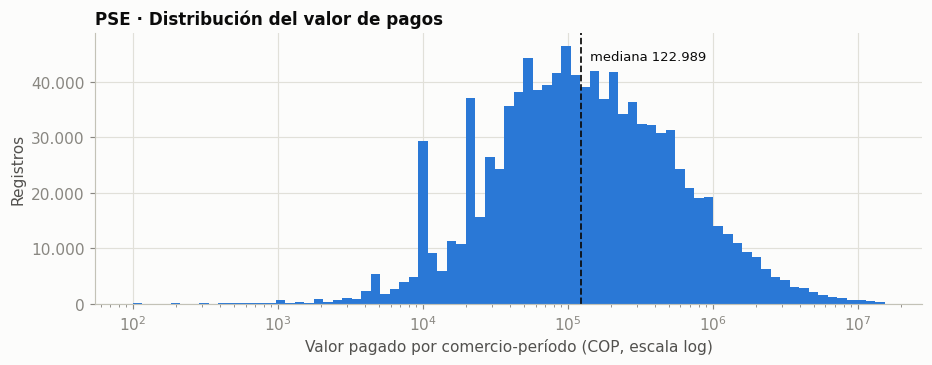

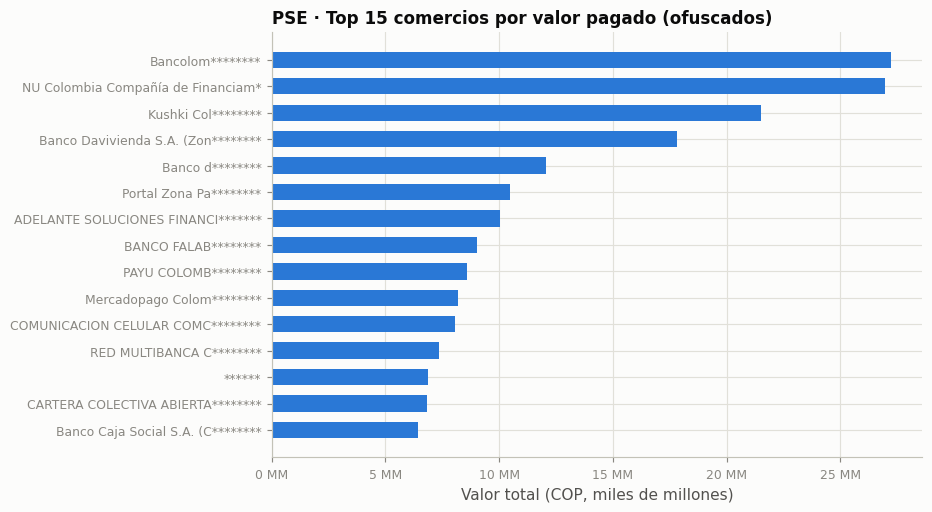

In [20]:
# === 4.2 Distribución de valores y top comercios ===
display(pdig[['Valor', 'Cantidad']].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(1))

v = pdig.loc[pdig['Valor'] > 0, 'Valor']
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(v, bins=np.logspace(np.log10(max(v.min(), 100)), np.log10(v.quantile(0.999)), 80), color=AZUL)
ax.set_xscale('log')
ax.axvline(v.median(), color='#0b0b0b', lw=1.2, ls='--')
ax.text(v.median() * 1.15, ax.get_ylim()[1] * 0.9, f'mediana {fmt_es(v.median())}', fontsize=9)
ax.set_xlabel('Valor pagado por comercio-período (COP, escala log)'); ax.set_ylabel('Registros')
ax.yaxis.set_major_formatter(FMT_MILES)
ax.set_title('PSE · Distribución del valor de pagos', loc='left')
plt.tight_layout(); plt.show()

top_val = pdig.groupby('Comercio', observed=True)['Valor'].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([str(x)[:34] for x in top_val.index[::-1]], top_val.values[::-1], color=AZUL, height=0.62)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: fmt_es(x/1e9) + ' MM'))
ax.set_xlabel('Valor total (COP, miles de millones)')
ax.set_title('PSE · Top 15 comercios por valor pagado (ofuscados)', loc='left')
ax.tick_params(labelsize=8.5)
plt.tight_layout(); plt.show()

,sum,count,pct_valor
categoria,,,
Otros / no identificado,1.682784e+11,524082,39.5
Financiero / crédito,1.627015e+11,248561,38.2
Pasarela / agregador,5.656595e+10,156156,13.3
Educación,1.196535e+10,19533,2.8
Telco / utilities,8.279949e+09,59194,1.9
Gobierno / impuestos,6.909525e+09,20667,1.6
Seguridad social,6.010594e+09,7808,1.4
Viajes / transporte,2.243042e+09,3487,0.5
Salud,1.648716e+09,5237,0.4


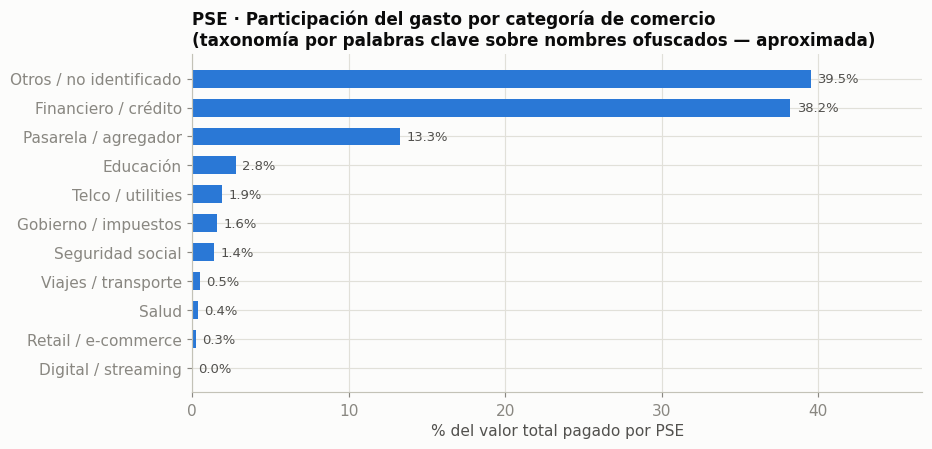

In [21]:
# === 4.3 Taxonomía de comercios (caso 4 · Comportamientos de Consumo) ===
TAXONOMIA = {
    'Financiero / crédito': ['BANCO', 'BANCOL', 'DAVIVI', 'NEQUI', 'FONDO', 'CREDI', 'FINANC',
                             'COOPERATIV', 'SEGURO', 'SURA', 'PORVENIR', 'COLPENS', 'PROTECC',
                             'FIDUC', 'BBVA', 'TUYA', 'LEASING', 'CAPITAL'],
    'Gobierno / impuestos': ['HACIENDA', 'DIAN', 'ALCALD', 'GOBERNAC', 'MINISTER', 'SECRETAR',
                             'DISTRITAL', 'MUNICIP', 'TRANSITO', 'RUNT', 'ICFES', 'SENA', 'NOTARIA'],
    'Seguridad social': ['APORTES', 'PILA', 'SOI', 'COMPENSAR', 'COLSUBSIDIO', 'CAFAM', 'EPS', 'ARL'],
    'Pasarela / agregador': ['PAYU', 'PLACETOPAY', 'PLACE TO PAY', 'EPAYCO', 'WOMPI', 'MERCADO',
                             'PAYVALIDA', 'KUSHKI', 'ZONA', 'GOU', 'TUCOMPRA', 'PAGOS'],
    'Telco / utilities': ['CLARO', 'MOVISTAR', 'TIGO', 'WOM', 'ETB', 'EPM', 'EMCALI', 'CODENSA',
                          'ENEL', 'VANTI', 'GAS', 'ACUEDUCTO', 'AGUAS', 'ENERGIA', 'AIRE'],
    'Retail / e-commerce': ['EXITO', 'OLIMPICA', 'ALKOSTO', 'KTRONIX', 'FALABELLA', 'HOMECENTER',
                            'JUMBO', 'MAKRO', 'PRICESMART', 'AMAZON', 'TEMU', 'SHEIN', 'LIBRE'],
    'Educación': ['UNIVERSIDAD', 'COLEGIO', 'ICETEX', 'EDUCA', 'ACADEM', 'INSTITUT', 'CORPORAC'],
    'Salud': ['CLINICA', 'HOSPITAL', 'FARMA', 'DROGUER', 'LABORATOR', 'MEDIC', 'SALUD'],
    'Viajes / transporte': ['AVIANCA', 'LATAM', 'WINGO', 'SATENA', 'EXPRESO', 'BOLIVARIANO',
                            'HOTEL', 'DESPEGAR', 'BOOKING', 'TRANSPORT', 'VIAJES', 'TURIS'],
    'Digital / streaming': ['NETFLIX', 'SPOTIFY', 'DISNEY', 'HBO', 'PRIME', 'GOOGLE', 'APPLE',
                            'MICROSOFT', 'STEAM', 'RAPPI', 'UBER', 'DIDI', 'GAMES'],
}

def clasificar(nombre):
    n = str(nombre).upper()
    for cat, claves in TAXONOMIA.items():
        if any(k in n for k in claves):
            return cat
    return 'Otros / no identificado'

cat_comercio = pdig['Comercio'].map({c: clasificar(c) for c in pdig['Comercio'].dropna().unique()})
gasto_cat = (pdig.assign(categoria=cat_comercio)
             .groupby('categoria', observed=True)['Valor'].agg(['sum', 'count'])
             .sort_values('sum', ascending=False))
gasto_cat['pct_valor'] = gasto_cat['sum'] / gasto_cat['sum'].sum() * 100
display(gasto_cat.round(1))

fig, ax = plt.subplots(figsize=(9, 4.4))
d = gasto_cat['pct_valor'][::-1]
ax.barh(d.index, d.values, color=AZUL, height=0.62)
for i, vv in enumerate(d.values):
    ax.text(vv + 0.4, i, f'{vv:.1f}%', va='center', fontsize=9, color='#52514e')
ax.set_xlim(0, d.max() * 1.18)
ax.set_xlabel('% del valor total pagado por PSE')
ax.set_title('PSE · Participación del gasto por categoría de comercio\n'
             '(taxonomía por palabras clave sobre nombres ofuscados — aproximada)', loc='left')
plt.tight_layout(); plt.show()

M['pd']['pct_otros_taxonomia'] = round(float(
    gasto_cat.loc[gasto_cat.index == 'Otros / no identificado', 'pct_valor'].sum()), 1)

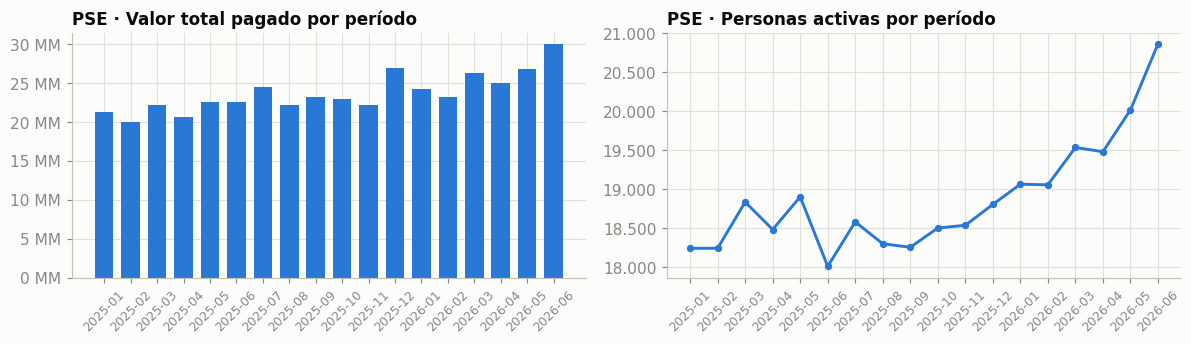

,valor,transacciones,personas
periodo,,,
2025-01,2.123179e+10,91305,18237
2025-02,1.999611e+10,91251,18237
2025-03,2.216739e+10,102032,18830
2025-04,2.055077e+10,93657,18478
2025-05,2.255745e+10,98664,18897
2025-06,2.249357e+10,93645,18005
2025-07,2.438545e+10,97619,18576
2025-08,2.216332e+10,94250,18295
2025-09,2.314626e+10,94102,18250


In [22]:
# === 4.4 Evolución temporal ===
gp = pdig.groupby('periodo', observed=True).agg(valor=('Valor', 'sum'),
                                                transacciones=('Cantidad', 'sum'),
                                                personas=('Número documento', 'nunique'))
x = gp.index.astype(str)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].bar(x, gp['valor'], color=AZUL, width=0.7)
axes[0].set_title('PSE · Valor total pagado por período', loc='left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: fmt_es(v/1e9) + ' MM'))
axes[1].plot(x, gp['personas'], color=AZUL, lw=2, marker='o', ms=4)
axes[1].set_title('PSE · Personas activas por período', loc='left')
axes[1].yaxis.set_major_formatter(FMT_MILES)
for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=8.5)
plt.tight_layout(); plt.show()
display(gp.round(0))

**Lectura de la sección 4.** PSE es el *proxy de capacidad de gasto*: cuánto paga cada persona, a qué tipo de comercio y con qué recurrencia. La taxonomía por palabras clave es aproximada (los nombres están ofuscados y truncados), pero ya separa gasto financiero, gobierno, telco/utilities y consumo — suficiente para prototipar la segmentación RFM y las propensiones del caso 4.

---
## 5 · Cruce entre fuentes: la triangulación del negocio

El valor diferencial de ACH Data no está en cada fuente por separado sino en su **cruce por persona y período**: IBC declarado (SS) × dinero recibido (ACH/Transfiya) × gasto (PSE). Aquí se cuantifica cuántas personas son cruzables y se ilustra la triangulación del *Estimador de Ingresos* (caso 2).

> Recordatorio: la llave (`Número documento`) está enmascarada → el cruce es aproximado (puede unir personas distintas con el mismo prefijo) y las dos fuentes transaccionales están truncadas, por lo que el solapamiento real solo puede ser **mayor** al observado.

Personas únicas en el universo combinado: 40.892
Personas en las tres fuentes            : 18.319 (44.8%)


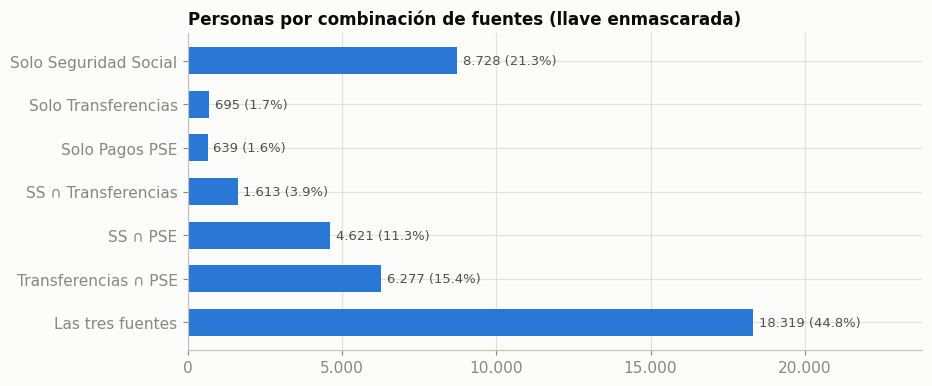

In [23]:
# === 5.1 Solapamiento de personas entre las 3 fuentes ===
S = set(ss['Número de documento'].dropna())
T = set(tr['Número documento'].dropna())
P = set(pdig['Número documento'].dropna())

combos = {
    'Solo Seguridad Social': len(S - T - P),
    'Solo Transferencias': len(T - S - P),
    'Solo Pagos PSE': len(P - S - T),
    'SS ∩ Transferencias': len((S & T) - P),
    'SS ∩ PSE': len((S & P) - T),
    'Transferencias ∩ PSE': len((T & P) - S),
    'Las tres fuentes': len(S & T & P),
}
total_univ = len(S | T | P)
print(f'Personas únicas en el universo combinado: {fmt_es(total_univ)}')
print(f'Personas en las tres fuentes            : {fmt_es(combos["Las tres fuentes"])} '
      f'({combos["Las tres fuentes"]/total_univ*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 3.8))
nombres = list(combos)[::-1]; vals = [combos[k] for k in nombres]
ax.barh(nombres, vals, color=AZUL, height=0.62)
for i, vv in enumerate(vals):
    ax.text(vv + max(vals) * 0.01, i, f'{fmt_es(vv)} ({vv/total_univ*100:.1f}%)',
            va='center', fontsize=9, color='#52514e')
ax.set_xlim(0, max(vals) * 1.3)
ax.xaxis.set_major_formatter(FMT_MILES)
ax.set_title('Personas por combinación de fuentes (llave enmascarada)', loc='left')
plt.tight_layout(); plt.show()

M['cruce'] = {'universo': total_univ, **{k: v for k, v in combos.items()}}

Personas con las tres señales simultáneas: 14.917


,IBC salud (mediana),Recibido mensual (ACH+Transfiya),Gasto mensual PSE
IBC salud (mediana),1.000,0.238,0.220
Recibido mensual (ACH+Transfiya),0.238,1.000,0.274
Gasto mensual PSE,0.220,0.274,1.000


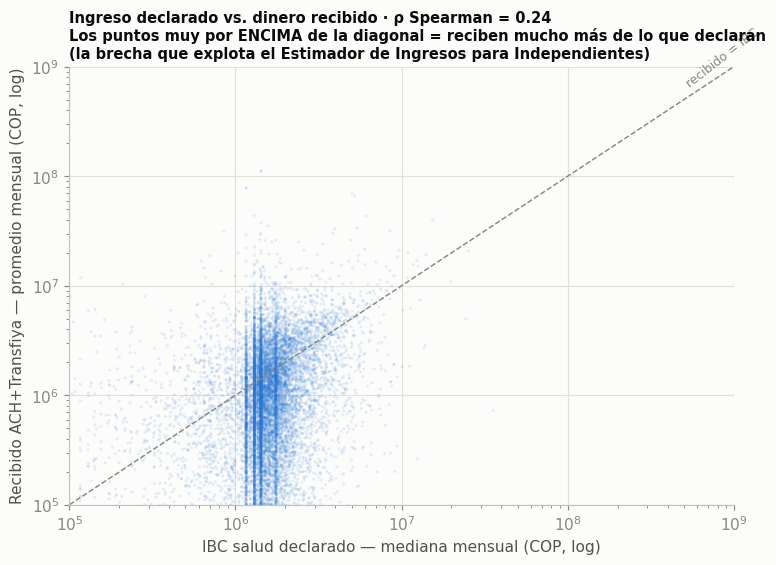

Personas que reciben >2× su IBC declarado: 11.8% ← mercado objetivo del caso de uso 2


In [24]:
# === 5.2 Triangulación ilustrativa: IBC declarado vs dinero recibido vs gasto PSE ===
# Un valor por persona: agregados persona-período de-duplicados y promediados.
ibc_p = (ss.groupby('Número de documento', observed=True)['Ingreso base salud']
           .agg(lambda s: s[s > 0].median()).rename('IBC salud (mediana)'))
rec_p = (tr.drop_duplicates(['Número documento', 'Periodo'])
           .groupby('Número documento', observed=True)['Total recibidas periodo']
           .mean().rename('Recibido mensual (ACH+Transfiya)'))
gas_p = (pdig.drop_duplicates(['Número documento', 'Periodo'])
             .groupby('Número documento', observed=True)['Total pagos periodo']
             .mean().rename('Gasto mensual PSE'))

tri = pd.concat([ibc_p, rec_p, gas_p], axis=1, join='inner').replace(0, np.nan).dropna()
print(f'Personas con las tres señales simultáneas: {fmt_es(len(tri))}')

rho = tri.corr(method='spearman')
display(rho.round(3))

muestra = tri.sample(min(40_000, len(tri)), random_state=42)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(muestra.iloc[:, 0], muestra.iloc[:, 1], s=4, alpha=0.12, color=AZUL, edgecolors='none')
lim = [1e5, 1e9]
ax.plot(lim, lim, color='#898781', lw=1, ls='--')
ax.text(lim[1] * 0.5, lim[1] * 0.65, 'recibido = IBC', fontsize=8.5, color='#898781', rotation=38)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('IBC salud declarado — mediana mensual (COP, log)')
ax.set_ylabel('Recibido ACH+Transfiya — promedio mensual (COP, log)')
rho_xy = tri.iloc[:, 0].corr(tri.iloc[:, 1], method='spearman')
ax.set_title(f'Ingreso declarado vs. dinero recibido · ρ Spearman = {rho_xy:.2f}\n'
             'Los puntos muy por ENCIMA de la diagonal = reciben mucho más de lo que declaran\n'
             '(la brecha que explota el Estimador de Ingresos para Independientes)', loc='left',
             fontsize=10)
plt.tight_layout(); plt.show()

M['cruce']['personas_triangulables'] = int(len(tri))
M['cruce']['rho_ibc_vs_recibido'] = round(float(rho_xy), 3)
pct_brecha = (tri.iloc[:, 1] > 2 * tri.iloc[:, 0]).mean() * 100
print(f'Personas que reciben >2× su IBC declarado: {pct_brecha:.1f}% '
      '← mercado objetivo del caso de uso 2')
M['cruce']['pct_recibe_mas_2x_ibc'] = round(float(pct_brecha), 1)

---
## 6 · Hallazgos y conclusiones

### 6.1 Calidad y estructura de los datos

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | **Dos fuentes truncadas al límite de Excel** (1.048.574 filas): Transferencias y PSE son muestras, no el universo | La coherencia entre agregados pre-calculados y detalle es 88,4% (±1%): el detalle faltante quedó fuera del archivo |
| 2 | **Ventanas temporales distintas**: SS cubre 36 meses (2023-07 → 2026-06); Transferencias y PSE solo 18 (2025-01 → 2026-06) | El análisis longitudinal cruzado solo es válido en la ventana común 2025-01 → 2026-06 |
| 3 | **Nulos mayormente estructurales, no de calidad**: `Novedades` 37,6% (= períodos sin novedad), contrapartes de Transferencias dependen del sentido (RECIBIDO ↔ originador, ENVIADO ↔ receptor) | Crosstab sentido × nulidad = 100% estructural |
| 4 | **Ofuscación agresiva**: llave de persona enmascarada en los últimos dígitos → identidad *aproximada*; `Entidad autorizadora` (PSE) 100% enmascarada (sin valor analítico); nombres de comercios truncados | 39,5% del valor PSE queda sin clasificar en la taxonomía por palabras clave |
| 5 | Duplicados exactos marginales: 50 filas en SS (~0,01%) y 7.291 en Transferencias (0,7%) | Ver sección de perfil de cada dataset |

### 6.2 Señales de negocio confirmadas en los datos

1. **Informalidad / independientes (caso 2):** el **57,6%** de los registros PILA cotiza **salud sin pensión** — exactamente la señal `diasPension = 0` que la metodología del catálogo identificó como marcador de ingreso no declarado.
2. **La brecha declarado-vs-real existe y es grande:** la correlación (Spearman) entre el IBC salud declarado y el dinero recibido por ACH/Transfiya es de apenas **ρ = 0,24**, y el **11,8%** de las 14.917 personas triangulables recibe **más del doble** de lo que declara. Ese es el mercado del *Estimador de Ingresos para Independientes*.
3. **Rotación laboral visible:** 10,1% de registros con novedad ING y 8,9% con RET; además 42,4% con variación transitoria de salario → insumo directo del motor de alertas (caso 1).
4. **Transfiya domina la frecuencia** (64,8% de los registros de transferencias) con tickets pequeños; ACH concentra los valores altos — dos regímenes de uso que un modelo debe tratar por separado.
5. **19,3% de transferencias a cuenta propia** — la señal de estructuración/autolavado que alimentan los modelos AML del catálogo.
6. **El gasto PSE está dominado por servicio de deuda:** Financiero/crédito 38,2% + pasarelas 13,3% del valor total; el consumo discrecional (retail, viajes, streaming) es minoritario en valor. La taxonomía del campo `Comercio` funciona, pero requiere un catálogo maestro de comercios para reducir el 39,5% "no identificado".
7. **El cruce entre fuentes es viable hoy:** 18.319 personas (44,8% del universo combinado de 40.892) aparecen en las tres fuentes — suficiente para entrenar los modelos de los casos 2, 3 y 4 sin datos externos.

### 6.3 Implicaciones para los 5 casos de uso

| Caso | ¿Viable con estos extractos? | Nota |
|---|---|---|
| ① Monitoreo y Alertas | ✅ Sí | Novedades ING/RET/VSP + series mensuales de flujo ya son calculables |
| ② Ingresos independientes | ✅ Sí — el más respaldado | Brecha IBC vs recibido cuantificada (ρ=0,24; 11,8% >2×) |
| ③ Flujo de caja | ✅ Sí, con cautela | El FCM requiere detalle completo: el truncamiento sesga la suma de egresos |
| ④ Comportamientos de consumo | ⚠ Parcial | Requiere catálogo maestro de comercios (39,5% sin clasificar) |
| ⑤ Análisis y segmentos | ⚠ Parcial | No hay campo `ubicacion` en estos extractos → sin dimensión geográfica |

### 6.4 Limitaciones y recomendaciones para la siguiente fase (preparación de datos)

- **Todas las cifras son direccionales**: muestras truncadas + identidad enmascarada ⇒ no extrapolar volúmenes al universo ACH.
- Solicitar los extractos en **CSV/parquet** (no XLSX) para eliminar el truncamiento, con **llave de persona hasheada de forma consistente** (no enmascarada) entre fuentes.
- Solicitar **diccionario de datos formal** (códigos de tipo planilla, novedades, clase aportante) y un **catálogo maestro de comercios PSE** con categoría/CIIU.
- Homologar la **ventana temporal** de las tres fuentes; incluir el campo de **ubicación** del módulo de contacto para habilitar el caso 5.
- De-duplicar los agregados (`Promedio…`, `Total… periodo`) antes de modelar, o descartarlos y recalcularlos desde el detalle.

In [25]:
# === Exportar métricas clave del EDA ===
(PROC / 'eda_metrics.json').write_text(
    json.dumps(M, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
print(json.dumps(M, indent=2, ensure_ascii=False, default=str))

{
  "filas": {
    "seguridad_social": 743406,
    "transferencias": 1048574,
    "pagos_digitales": 1048574
  },
  "ss": {
    "personas": 33281,
    "aportantes": 29957,
    "periodos": [
      "2023-07",
      "2026-06"
    ],
    "reg_por_persona_mediana": 21.0,
    "ibc_salud_mediana": 1750905.0,
    "pct_salud_sin_pension": 57.63,
    "pct_retiro": 8.87,
    "pct_ingreso": 10.06
  },
  "tr": {
    "personas": 26904,
    "periodos": [
      "2025-01",
      "2026-06"
    ],
    "pct_cuenta_propia": 19.25,
    "pct_agregado_coincide": 88.4
  },
  "pd": {
    "personas": 29856,
    "comercios": 3475,
    "periodos": [
      "2025-01",
      "2026-06"
    ],
    "pct_otros_taxonomia": 39.5
  },
  "cruce": {
    "universo": 40892,
    "Solo Seguridad Social": 8728,
    "Solo Transferencias": 695,
    "Solo Pagos PSE": 639,
    "SS ∩ Transferencias": 1613,
    "SS ∩ PSE": 4621,
    "Transferencias ∩ PSE": 6277,
    "Las tres fuentes": 18319,
    "personas_triangulables": 14917,
    "rh